In [2]:
import cv2

url = "video_benign_Pt-num-000_vid-num-000.mp4"
cap = cv2.VideoCapture(url)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imshow("Streaming Video", frame)
    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()


In [1]:
import torch
import cv2
import groundingdino.datasets.transforms as T
from groundingdino.util.inference import Model
from PIL import Image
import matplotlib.pyplot as plt


In [4]:
model = Model(model_config_path="/home/teaching/ADL-project/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py",
              model_checkpoint_path="/home/teaching/ADL-project/GroundingDINO/weights/groundingdino_swint_ogc.pth")


final text_encoder_type: bert-base-uncased


In [12]:
prompts = "malignant tissue, benign tissue"

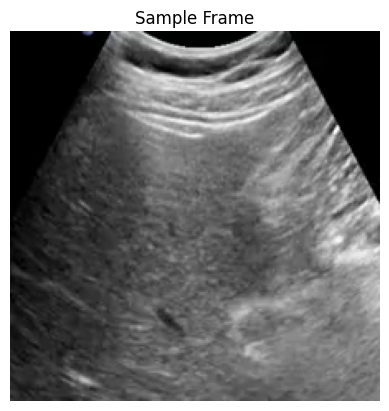

In [6]:
video_path = "/home/teaching/ADL-project/video_benign_Pt-num-000_vid-num-000.mp4"

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.title("Sample Frame")
plt.axis("off")
plt.show()


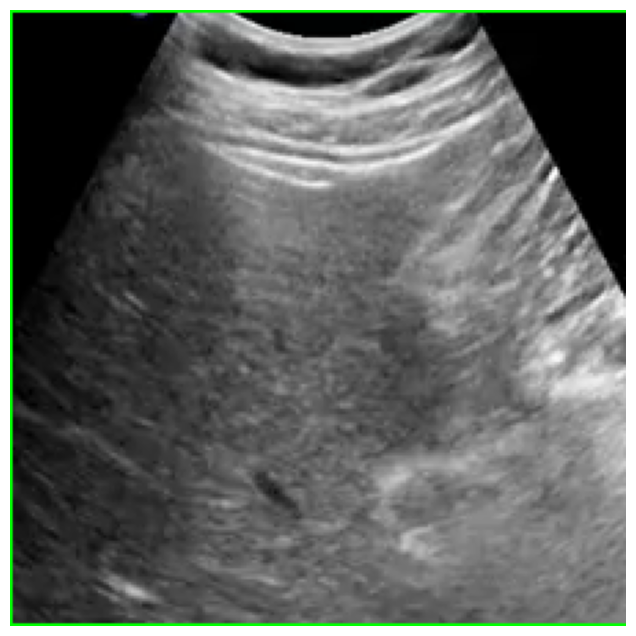

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def draw_boxes_cv(image_pil, detections, labels, color=(0, 255, 0), thickness=1):
    img = np.array(image_pil)[:, :, ::-1].copy()

    if hasattr(detections, "xyxy"):
        boxes = detections.xyxy
    else:
        boxes = np.array(detections)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        label = labels[i] if i < len(labels) else "Object"
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return img[:, :, ::-1]


image_pil = Image.fromarray(frame_rgb)

boxes, phrases = model.predict_with_caption(
    frame_rgb[:, :, ::-1],  # RGB → BGR
    prompts,
    box_threshold=0.35,
    text_threshold=0.25
)

annotated_frame = draw_boxes_cv(image_pil, boxes, phrases)

plt.figure(figsize=(8, 8))
plt.imshow(annotated_frame)
plt.axis("off")
plt.show()


In [40]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from groundingdino.util.inference import Model

model = Model(
    model_config_path="/home/teaching/ADL-project/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py",
    model_checkpoint_path="/home/teaching/ADL-project/GroundingDINO/weights/groundingdino_swint_ogc.pth"
)

prompts  = "amall. benign. tumour. lession."


video_path = "/home/teaching/ADL-project/video_benign_Pt-num-000_vid-num-000.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Could not open video.")
else:
    print(" Video loaded successfully.")

output_path = "/home/teaching/ADL-project/GroundingDINO/output_detected.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

def draw_boxes(image, boxes, labels, color=(0, 255, 0)):
    img = image.copy()
    if hasattr(boxes, "xyxy"):
        boxes = boxes.xyxy
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 1)
        label = labels[i] if i < len(labels) else "Object"
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img

frame_idx = 0
while True:
    ret, frame_bgr = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    boxes, phrases = model.predict_with_caption(
        frame_rgb[:, :, ::-1],  # RGB -> BGR
        prompts,
        box_threshold=0.25,
        text_threshold=0.25
    )

    if boxes is None or len(boxes) == 0:
        out.write(frame_bgr)
        continue

    frame_with_boxes = draw_boxes(frame_bgr, boxes, phrases)

    out.write(frame_with_boxes)

    frame_idx += 1
    if frame_idx % 10 == 0:
        print(f"Processed frame {frame_idx}")

cap.release()
out.release()
print(f" Detection video saved at: {output_path}")


final text_encoder_type: bert-base-uncased
 Video loaded successfully.
Processed frame 10
Processed frame 20
Processed frame 30
Processed frame 40
Processed frame 50
Processed frame 60
Processed frame 70
Processed frame 80
Processed frame 90
Processed frame 100
Processed frame 110
Processed frame 120
Processed frame 130
Processed frame 140
 Detection video saved at: /home/teaching/ADL-project/GroundingDINO/output_detected.mp4


In [ ]:
fgbg = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    fgmask = fgbg.apply(frame)
    fgmask = cv2.GaussianBlur(fgmask, (5, 5), 0)
    _, thresh = cv2.threshold(fgmask, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for c in contours:
        if cv2.contourArea(c) > 500:  # ignore tiny movement
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(frame, "Moving object", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    cv2.imshow("Detection", frame)
    if cv2.waitKey(30) & 0xFF == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()



In [46]:
import os

output_dir = "/home/teaching/ADL-project/notebooks/mitanshi/dino_frames"
mask_dir = "/home/teaching/ADL-project/notebooks/mitanshi/dino_masks"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
fgbg = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)

frame_id = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    fgmask = fgbg.apply(frame)
    fgmask = cv2.GaussianBlur(fgmask, (5,5), 0)
    _, thresh = cv2.threshold(fgmask, 110, 255, cv2.THRESH_BINARY)

    if frame_id % 10 == 0:
        cv2.imwrite(f"{output_dir}/frame_{frame_id:05d}.jpg", frame)
        cv2.imwrite(f"{mask_dir}/mask_{frame_id:05d}.jpg", thresh)
    frame_id += 1

cap.release()
print(f"Extracted {frame_id//10} frames for fine-tuning")


Extracted 14 frames for fine-tuning


In [49]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from dino import utils, vision_transformer as vits
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = "/home/teaching/ADL-project/dino_frames"
save_path = "/home/teaching/ADL-project/dino_checkpoints"
os.makedirs(save_path, exist_ok=True)
batch_size = 16
epochs = 50
lr = 1e-4

transform = T.Compose([
    T.Resize((224,224)),
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.ToTensor(),
])

dataset = ImageFolder(root=data_path, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

model = vits.__dict__["vit_small"](patch_size=16)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

for epoch in range(epochs):
    for i, (x, _) in enumerate(loader):
        x = x.to(device)
        z = model(x)
        loss = (z ** 2).mean() 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), f"{save_path}/dino_selfsup_{epoch+1:03d}.pth")

print(" Self-supervised fine-tuning complete!")


ImportError: cannot import name 'utils' from 'dino' (/home/teaching/ADL-project/notebooks/mitanshi/dino.py)